In [1]:
clean_up = True # if True, remove all gams related files from working folder before starting
%run stdPackages.ipynb

*Load specific modules used here:*

In [2]:
os.chdir(main)
%run stdPlotting.ipynb
os.chdir(d['py'])
import mCGE

# Load and run calibrated model

We can use the calibrated in one of two ways: By loading the model instance itself or by loading data and GAMS code. 

## 1. Run from model instance

*Load model:*

In [3]:
t0 = 2019
name = f'vGRS{t0}CGE'
M = mCGE.WasteManagementCGE.load(os.path.join(d['data'], name)) # load model
ws = M.ws 
db0 = M.db.copy() # store initial solution

### 1.1. Simple shocks through python

#### A. *Increase VAT on waste generation with 10 percentage points:*

Define new taxes:

In [4]:
newTaxes = adj.rc_pd(M.db('tauD'), M.db('nw_D'))+0.1 # subset all input taxes and focus on waste domestic waste treatment (nw_D)
M.db.aom(newTaxes, name = 'tauD', priority = 'second') # Add or merge (aom) the new taxes to the main database. Priority = 'second' means that if model already has data, it overwrites existing values in overlapping domains.

Run "simple" model:

In [5]:
M.db.mergeInternal() # write .gdx file based on Python database with updated taxes.
sol = M.solve(state = 'B') # Solve model in baseline state 'B' (as opposed to calibration state 'C')

Plot results and compare with baseline solution, e.g. amount of metal waste:

In [9]:
tPlot = M.db('t').sort_values()[0:25]
def getWaste(dbi, wtype):
    return adj.rc_pd(dbi('qWS'), tPlot).xs(wtype,level='m').groupby('t').sum()

Waste generation as function of the tax:

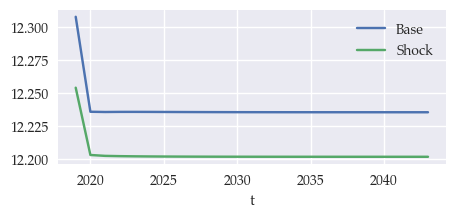

In [10]:
pd.DataFrame({'Base': getWaste(db0, 'Metal'), 'Shock': getWaste(sol,'Metal')}).plot(figsize=(5,2));

#### B. *More efficient recycling of plastic:*

Revert to initial level of taxes before the new shock:

In [11]:
M.db.aom(db0('tauD'), name = 'tauD', priority = 'second')

Increase $\overline{\alpha}$ in recycling technoogy for plastic:

In [12]:
new_ᾱ = adj.rc_pd(M.db('WTD_alphau'), pd.Index(['Plastic'], name = 'm'))+0.5
M.db.aom(new_ᾱ, name = 'WTD_alphau', priority = 'second')
M.db.mergeInternal()
sol = M.solve(state='B')

Plot plastic waste:

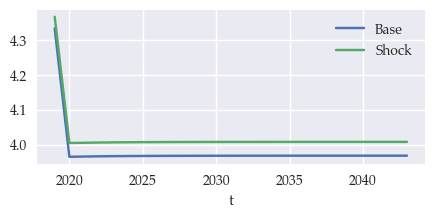

In [14]:
pd.DataFrame({'Base': getWaste(db0, 'Plastic'), 'Shock': getWaste(sol,'Plastic')}).plot(figsize=(5,2));

### 1.2. Large shocks through python

Revert to initial $\overline{\alpha}$ levels before the new shock:

In [11]:
M.db.aom(db0('WTD_alphau'), name = 'WTD_alphau', priority = 'second')

If we want to perform more numerically tricky shocks, we can rely on the ```jSolve``` relaxation method. The method essentially splits up the problem of solving the model into $n$ smaller steps. The main arguments for the solution method are:
* ```n``` (required): Number of steps taken. Use higher $n$ for tricky problems.
* ```state = 'B'``` (optional): Reference the model solution state. *In our model we only calibration ('C') and baseline ('B') states*
* ```ϕ = 1``` (optional): Used to approach solution nonlinearly ($\phi>0$). $\phi = 1$ is linear. $\phi<1$ if the problem is numerically tricky close to the endpoint. $\phi>1$ if the problem is numerically tricky close to the initial point.
* ```solve = None``` (optional): Use to change the solve statement to something non-standard (rarely required).
* ```addJobOpt = None``` (optional): Use e.g. to create a checkpoint to start model simulations from.
* ```runJobOpt = none``` (optional): Use e.g. to run from a checkpoint (or use other options). 

For instance, say we want to make it cheaper to use waste for incineration:

In [12]:
M.db.aom(M.db('WTD_ge')-0.2, name = 'WTD_ge', priority = 'second')
M.db.mergeInternal()
sol = M.jSolve(25, state = 'B') # 

Plot the share of waste for waste incineration e.g. for paper:

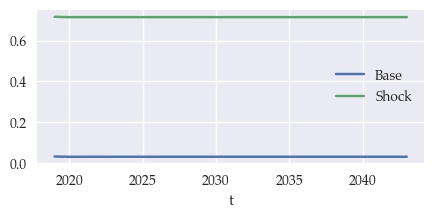

In [13]:
adj.rc_pd(pd.DataFrame({'Base': db0('WTD_e').xs('Paper',level='m'), 'Shock': sol('WTD_e').xs('Paper',level='m')}), tPlot).plot(figsize=(5,2));

Plot price of waste energy and quantity:

*Price:*

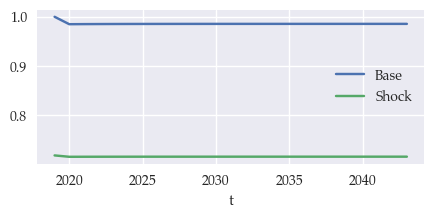

In [14]:
adj.rc_pd(pd.DataFrame({'Base': db0('p').xs('WasteE',level='n'), 'Shock': sol('p').xs('WasteE',level='n')}), tPlot).plot(figsize=(5,2));

*Quantity:*

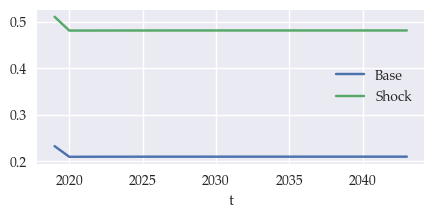

In [15]:
adj.rc_pd(pd.DataFrame({'Base': db0('qS').xs(('Waste','WasteE'),level=('s','n')), 'Shock': sol('qS').xs(('Waste','WasteE'),level=('s','n'))}), tPlot).plot(figsize=(5,2));

*Revert to original ```WTD_ge``` before next shock:*

In [16]:
M.db.aom(db0('WTD_ge'), name = 'WTD_ge', priority = 'second')

### 1.3. Using checkpoints

We can run shocks to the model in several steps using checkpoints. For example:
* Subsidize recycled materials from waste treatment firm. Inspect solution.
* From the starting point of the model with recycling subsidies, change some tax and solve again.

*First change to the data:*

In [17]:
subsidies = adj.rc_pd(M.db('tauS'), ('and', [M.db('sWaste'), M.db('nm_D')]))-0.1 # get relevant tax rates
M.db.aom(subsidies, name = 'tauS', priority = 'second')
M.db.mergeInternal()

Solve and store checkpoint:

In [18]:
cp0 = ws.add_checkpoint() # Gams object to store in
sol1 = M.solve(runJobOpt = {'checkpoint': cp0})

*Adjust share of waste being treated domestically:*

In [19]:
solveText = f"""
    uWS_D.fx[t,s,m]$(dWS[s,m]) = min(uWS_D0[t,s,m]+0.1, 1);
    {M.solveStatement()}
"""

Solve from the stored checkpoint:

In [20]:
sol2 = M.solve(text = solveText, addJobOpt = {'checkpoint': cp0})

## 2. Load code

Move all relevant gams and gdx files to the work folder where we store temporary files:

In [21]:
gms = os.path.join(d['gams'], f'{M.name}.gms') # name of gms file
gmy = os.path.join(d['gams'], f'{M.name}.gmy') # name of gmy file
gdx = os.path.join(d['data'], f'{M.db.name}.gdx') # name of database file
[shutil.copy(f, os.path.join(d['work'], os.path.basename(f))) for f in (gms,gmy,gdx)]; # create copies in work folder

To run GAMS from Python, we need a ```GamsWorkspace```. As we already have one open from above (ws), we just use that here. Otherwise, the following cell opens initializes a new one that works in the designated work folder:

In [22]:
# ws = gams.GamsWorkspace(working_directory = d['work']

Create ```GamsJob``` from file and run (this time, we haven't added any shocks to the data):

In [23]:
job = ws.add_job_from_file(os.path.join(d['work'], os.path.basename(gms)))
job.run() # run model

We can extract solution using:

In [24]:
soldb = GpyDB(job.out_db, ws = ws)

Now, we can similarly access variables e.g. capital stock in the energy sector:

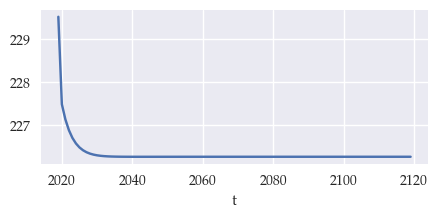

In [25]:
soldb('qD').xs(('Energy','K'),level=('s','n')).plot(figsize=(5,2));